In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# Step 2 : Data Preprocessing

train_gen = ImageDataGenerator(
    rescale = 1./255,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip=True
)

# Testing data generator
test_gen = ImageDataGenerator(
    rescale=1./255
)

In [3]:
# Dataset paths

train_path = r"C:\Users\LENOVO\Downloads\training_set\training_set"
test_path = r"C:\Users\LENOVO\Downloads\test_set\test_set"

In [4]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size = (128,128),
    batch_size = 32,
    class_mode = 'binary'
)
print(train_data.class_indices)

Found 8005 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


In [5]:
test_path =  r"C:\Users\LENOVO\Downloads\test_set\test_set"

In [6]:
test_data = test_gen.flow_from_directory(
    test_path,
    target_size = (128,128),
    batch_size = 32,
    class_mode = 'binary'
)
print(test_data.class_indices)

Found 2023 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


In [7]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer="adam",
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Step 6 : Early Stopping

es = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights = True
)

In [11]:
history=model.fit(
    train_data,
    validation_data=test_data,
    epochs=20,
    callbacks=[es]
)

Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 81s 316ms/step - accuracy: 0.5663 - loss: 0.7153 - val_accuracy: 0.6461 - val_loss: 0.6510
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 79s 316ms/step - accuracy: 0.6384 - loss: 0.6452 - val_accuracy: 0.6387 - val_loss: 0.6401
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 82s 325ms/step - accuracy: 0.6607 - loss: 0.6203 - val_accuracy: 0.6836 - val_loss: 0.6014
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 83s 331ms/step - accuracy: 0.6908 - loss: 0.5906 - val_accuracy: 0.7103 - val_loss: 0.5720
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 87s 347ms/step - accuracy: 0.7193 - loss: 0.5549 - val_accuracy: 0.7202 - val_loss: 0.5554
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 81s 321ms/step - accuracy: 0.7312 - loss: 0.5386 - val_accuracy: 0.7034 - val_loss: 0.5682
Epoch 7/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 80s 319ms/step - accuracy: 0.7475 - loss: 0.5167 - val_accuracy: 0.7583 - val_loss: 0.5006
Epoch 8/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 80s 319ms/step - accuracy: 0.7663 - loss: 0

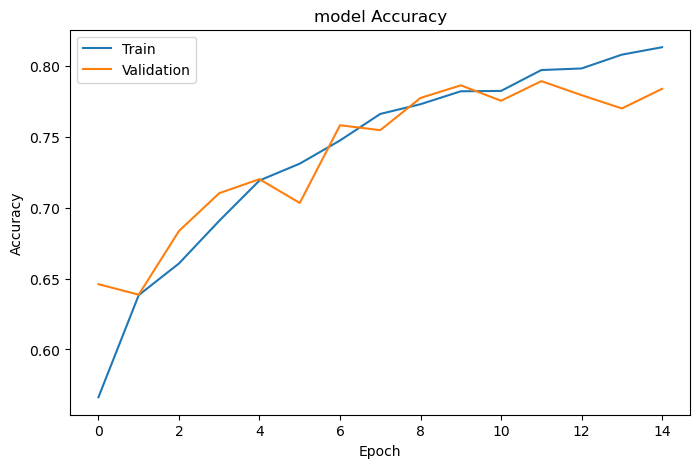

In [12]:
# Step 7 : Accuracy Graph

plt.figure(figsize =(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

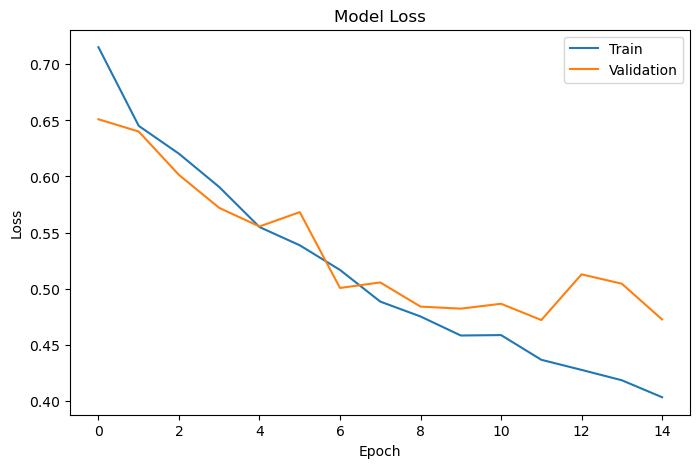

In [13]:
# Step 8 : Loss Graph

plt.figure(figsize= (8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [14]:
# Step 9 : Evaluate Model

loss,acc=model.evaluate(test_data)

print("Accuracy",acc)
print("Loss",loss)

64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.7894 - loss: 0.4720
Accuracy 0.7894216775894165
Loss 0.4719594419002533


In [15]:
# Step 10 : Save Model

model.save("cat_dog_cnn.h5")
print("Model saved successfully!")

Model saved successfully!


In [16]:
# Step 11 : Load Model

model = load_model("cat_dog_cnn.h5")

In [17]:
import pillow_avif
print("Installed Successfully")

Installed Successfully


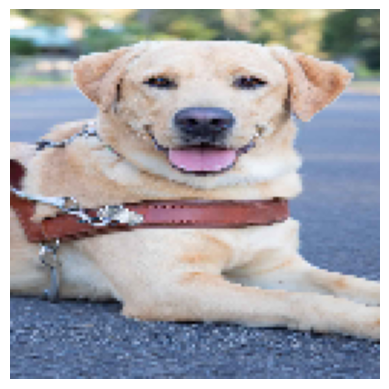

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
Prediction Score : 0.7056258
Dog


In [18]:
# Step 12 : Predict New Image

img_path = r"C:\Users\LENOVO\Downloads\dog.jpg"

img = image.load_img(
    img_path,
    target_size= (128,128)
)

plt.imshow(img)
plt.axis("off")
plt.show()

img_arr = image.img_to_array(img)
img_arr = img_arr / 255.0
img_arr = np.expand_dims(img_arr, axis= 0)

pred = model.predict(img_arr)

print("Prediction Score :" , pred[0][0])

if pred[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

In [19]:


if pred[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

Dog


In [23]:
print(train_data.class_indices)
print(pred)

{'cats': 0, 'dogs': 1}
[[0.7096957]]


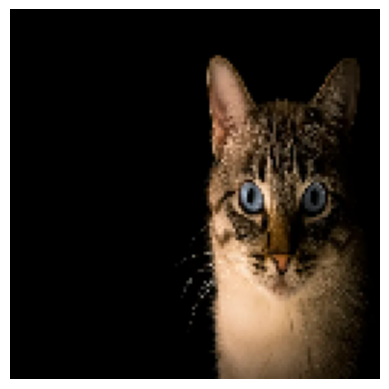

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
Prediction Score: 0.05181228
Cat


In [25]:
import pillow_avif
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

model = load_model ("cat_dog_cnn.h5")
img_path = r"C:\Users\LENOVO\Downloads\cat 2.webp"

img = image.load_img(img_path, target_size = (128,128))

plt.imshow(img)
plt.axis("off")
plt.show()

img_arr = image.img_to_array(img)
img_arr = img_arr / 255.0
img_arr = np.expand_dims(img_arr,axis = 0)

pred = model.predict(img_arr)

print("Prediction Score:", pred[0][0])

if pred [0][0] > 0.5:
    print("Dog")
else:
    print("Cat")